<a href="https://colab.research.google.com/github/Alishba-Nadeem1/RhombixTechnologies_Tasks/blob/main/compilace_factory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install kagglehub

In [6]:
import kagglehub

datasetPath = kagglehub.dataset_download(
    "trnhhnggiang/video-dataset-for-safe-and-unsafe-behaviours"
)

print(datasetPath)

100%|██████████| 9.32G/9.32G [01:59<00:00, 83.5MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/trnhhnggiang/video-dataset-for-safe-and-unsafe-behaviours/versions/1


In [7]:
import os

for root, dirs, files in os.walk(datasetPath):
    print("Folder:", root)
    print("Files:", files[:10])
    print("-" * 50)

Folder: /root/.cache/kagglehub/datasets/trnhhnggiang/video-dataset-for-safe-and-unsafe-behaviours/versions/1
Files: []
--------------------------------------------------
Folder: /root/.cache/kagglehub/datasets/trnhhnggiang/video-dataset-for-safe-and-unsafe-behaviours/versions/1/Video Dataset for Safe and Unsafe Behaviours
Files: []
--------------------------------------------------
Folder: /root/.cache/kagglehub/datasets/trnhhnggiang/video-dataset-for-safe-and-unsafe-behaviours/versions/1/Video Dataset for Safe and Unsafe Behaviours/Safe and Unsafe Behaviours Dataset
Files: []
--------------------------------------------------
Folder: /root/.cache/kagglehub/datasets/trnhhnggiang/video-dataset-for-safe-and-unsafe-behaviours/versions/1/Video Dataset for Safe and Unsafe Behaviours/Safe and Unsafe Behaviours Dataset/test
Files: []
--------------------------------------------------
Folder: /root/.cache/kagglehub/datasets/trnhhnggiang/video-dataset-for-safe-and-unsafe-behaviours/versions/1/V

In [8]:
!pip install torch torchvision opencv-python pillow tqdm

In [9]:
import os
import cv2
import torch
import random
import numpy as np

from PIL import Image
from tqdm import tqdm

from torchvision import transforms
from torchvision.models import mobilenet_v2

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from torch import nn

In [10]:
datasetPath = "/content/Safe and Unsafe Behaviours Dataset/train"

In [11]:
classMap = {
    "0_safe_walkway_violation":0,
    "1_unauthorized_intervention":1,
    "2_opened_panel cover":2,
    "3_carrying_overload_with_forklift":3,
    "4_safe_walkway":4,
    "5_authorized_intervention":5,
    "6_closed_panel_cover":6,
    "7_safe_carrying":7
}

In [12]:
def extractFrames(videoPath, frameCount=10):
    capture = cv2.VideoCapture(videoPath)

    totalFrames = int(
        capture.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    selectedFrames = []

    if totalFrames <= frameCount:
        frameIndexes = list(range(totalFrames))
    else:
        frameIndexes = np.linspace(
            0,
            totalFrames - 1,
            frameCount,
            dtype=int
        )

    currentIndex = 0

    while True:
        success, frame = capture.read()

        if not success:
            break

        if currentIndex in frameIndexes:
            frame = cv2.cvtColor(
                frame,
                cv2.COLOR_BGR2RGB
            )

            frame = cv2.resize(
                frame,
                (224,224)
            )

            selectedFrames.append(frame)

        currentIndex += 1

    capture.release()

    return selectedFrames

In [13]:
class VideoDataset(Dataset):

    def __init__(self, datasetPath):

        self.samples = []

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485,0.456,0.406],
                std=[0.229,0.224,0.225]
            )
        ])

        for folderName in os.listdir(datasetPath):

            folderPath = os.path.join(
                datasetPath,
                folderName
            )

            if not os.path.isdir(folderPath):
                continue

            label = classMap[folderName]

            for videoName in os.listdir(folderPath):

                videoPath = os.path.join(
                    folderPath,
                    videoName
                )

                self.samples.append(
                    (videoPath,label)
                )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self,index):

        videoPath,label = self.samples[index]

        frames = extractFrames(videoPath)

        processedFrames = []

        for frame in frames:
            image = Image.fromarray(frame)
            image = self.transform(image)
            processedFrames.append(image)

        tensorFrames = torch.stack(
            processedFrames
        )

        tensorFrames = tensorFrames.mean(
            dim=0
        )

        return tensorFrames,label

In [14]:
import os

basePath = "/root/.cache/kagglehub/datasets/trnhhnggiang/video-dataset-for-safe-and-unsafe-behaviours/versions/1/Video Dataset for Safe and Unsafe Behaviours/Safe and Unsafe Behaviours Dataset"

datasetPath = os.path.join(basePath, "train")

print(datasetPath)
print(os.path.exists(datasetPath))

/root/.cache/kagglehub/datasets/trnhhnggiang/video-dataset-for-safe-and-unsafe-behaviours/versions/1/Video Dataset for Safe and Unsafe Behaviours/Safe and Unsafe Behaviours Dataset/train
True


In [15]:
import os
import kagglehub

basePath = kagglehub.dataset_download(
    "trnhhnggiang/video-dataset-for-safe-and-unsafe-behaviours"
)

datasetPath = os.path.join(
    basePath,
    "Video Dataset for Safe and Unsafe Behaviours",
    "Safe and Unsafe Behaviours Dataset",
    "train"
)

print(datasetPath)
print(os.path.exists(datasetPath))

Using Colab cache for faster access to the 'video-dataset-for-safe-and-unsafe-behaviours' dataset.
/kaggle/input/video-dataset-for-safe-and-unsafe-behaviours/Video Dataset for Safe and Unsafe Behaviours/Safe and Unsafe Behaviours Dataset/train
True


In [ ]:
torch.save(
    model.state_dict(),
    "factoryComplianceModel.pth"
)

print("Model Saved")

In [17]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision.models import mobilenet_v2

In [18]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

In [19]:
import os

print(os.listdir())

['.config', 'sample_data']


In [20]:
VideoDataset

__main__.VideoDataset

In [21]:
trainDataset = VideoDataset(datasetPath)

print(len(trainDataset))

566


In [22]:
from torch.utils.data import DataLoader

trainLoader = DataLoader(
    trainDataset,
    batch_size=8,
    shuffle=True
)

print(len(trainLoader))

71


In [23]:
trainLoader = DataLoader(
    trainDataset,
    batch_size=8,
    shuffle=True
)

In [25]:
import torch
from torch import nn
from torchvision.models import mobilenet_v2

In [26]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


In [27]:
model = mobilenet_v2(weights="DEFAULT")

model.classifier[1] = nn.Linear(
    model.last_channel,
    8
)

model = model.to(device)
\
print("Model Loaded")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 116MB/s]


Model Loaded


In [28]:
lossFunction = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [29]:
epochs = 5

for epoch in range(epochs):

    model.train()

    totalLoss = 0

    for images, labels in trainLoader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = lossFunction(outputs, labels)

        loss.backward()

        optimizer.step()

        totalLoss += loss.item()

    averageLoss = totalLoss / len(trainLoader)

    print(f"Epoch {epoch+1}/{epochs} Loss: {averageLoss:.4f}")

Epoch 1/5 Loss: 1.4076
Epoch 2/5 Loss: 0.9666
Epoch 3/5 Loss: 0.8567
Epoch 4/5 Loss: 0.7252
Epoch 5/5 Loss: 0.6234


In [32]:
testPath = "/root/.cache/kagglehub/datasets/trnhhnggiang/video-dataset-for-safe-and-unsafe-behaviours/versions/1/Video Dataset for Safe and Unsafe Behaviours/Safe and Unsafe Behaviours Dataset/test"

testDataset = VideoDataset(testPath)

testLoader = DataLoader(
    testDataset,
    batch_size=8,
    shuffle=False
)

print(len(testDataset))

125


In [33]:
print(model)
print(device)
print(len(testLoader))


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [34]:
model.eval()

correctPredictions = 0
totalSamples = 0

with torch.no_grad():

    for images, labels in testLoader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictedLabels = torch.argmax(
            outputs,
            dim=1
        )

        totalSamples += labels.size(0)

        correctPredictions += (
            predictedLabels == labels
        ).sum().item()

accuracy = (
    100 *
    correctPredictions /
    totalSamples
)

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 60.00%


In [35]:
severityMap = {
    "SafeWalkwayViolation": "CRITICAL",
    "UnauthorizedIntervention": "HIGH",
    "OpenedPanelCover": "LOW",
    "CarryingOverloadWithForklift": "HIGH",
    "SafeWalkway": "SAFE",
    "AuthorizedIntervention": "SAFE",
    "ClosedPanelCover": "SAFE",
    "SafeCarrying": "SAFE"
}

In [36]:
policyMap = {
    "SafeWalkwayViolation":"Section 3.3.2",
    "UnauthorizedIntervention":"Section 4.3.2",
    "OpenedPanelCover":"Section 5.2.2",
    "CarryingOverloadWithForklift":"Section 6.3.2"
}

In [37]:
{
 "eventId": "...",
 "timestamp": "...",
 "clipId": "...",
 "behaviorClass": "...",
 "severity": "...",
 "policySection": "..."
}

{'eventId': '...',
 'timestamp': '...',
 'clipId': '...',
 'behaviorClass': '...',
 'severity': '...',
 'policySection': '...'}

In [39]:
import sqlite3

connection = sqlite3.connect("violations.db")

cursor = connection.cursor()

In [40]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS violations(
    eventId TEXT,
    timestamp TEXT,
    clipId TEXT,
    behaviorClass TEXT,
    severity TEXT,
    policySection TEXT
)
""")

connection.commit()

print("Table Created")

Table Created


In [41]:
cursor.execute("""
INSERT INTO violations
VALUES(
'001',
'2026-06-21 12:00:00',
'testVideo.mp4',
'UnauthorizedIntervention',
'HIGH',
'Section 4.3.2'
)
""")

connection.commit()

print("Inserted")

Inserted


In [48]:
classNames = {
    0:"SafeWalkwayViolation",
    1:"UnauthorizedIntervention",
    2:"OpenedPanelCover",
    3:"CarryingOverloadWithForklift",
    4:"SafeWalkway",
    5:"AuthorizedIntervention",
    6:"ClosedPanelCover",
    7:"SafeCarrying"
}

In [46]:
testVideoPath = "/root/.cache/kagglehub/datasets/trnhhnggiang/video-dataset-for-safe-and-unsafe-behaviours/versions/1/Video Dataset for Safe and Unsafe Behaviours/Safe and Unsafe Behaviours Dataset/test/1_unauthorized_intervention/1_te2.mp4"

In [49]:
from PIL import Image

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

def predictVideo(videoPath):

    frames = extractFrames(videoPath)

    processedFrames = []

    for frame in frames:

        image = Image.fromarray(frame)

        image = transform(image)

        processedFrames.append(image)

    videoTensor = torch.stack(
        processedFrames
    )

    videoTensor = videoTensor.mean(
        dim=0
    )

    videoTensor = videoTensor.unsqueeze(0)

    videoTensor = videoTensor.to(device)

    model.eval()

    with torch.no_grad():

        outputs = model(videoTensor)

        prediction = torch.argmax(
            outputs,
            dim=1
        ).item()

    return classNames[prediction]

In [50]:
testVideoPath = "/root/.cache/kagglehub/datasets/trnhhnggiang/video-dataset-for-safe-and-unsafe-behaviours/versions/1/Video Dataset for Safe and Unsafe Behaviours/Safe and Unsafe Behaviours Dataset/test/1_unauthorized_intervention/1_te2.mp4"

prediction = predictVideo(testVideoPath)

print("Predicted Class:", prediction)

Predicted Class: UnauthorizedIntervention


In [51]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 44.9 MB/s eta 0:00:00


2026-06-21 15:02:38.063 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 15:02:38.065 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 15:02:38.196 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-21 15:02:38.196 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 15:02:38.197 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 15:02:38.206 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 15:02:38.207 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

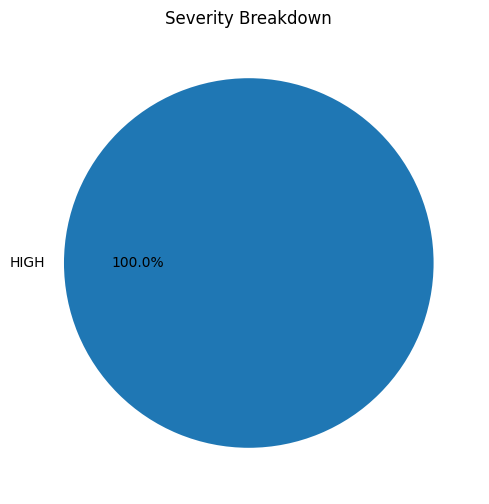

In [57]:
import streamlit as st
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="Factory Compliance Monitoring System",
    page_icon="🏭",
    layout="wide"
)

st.markdown(
    "<h1 style='text-align:center;color:#1E88E5;'>🏭 Factory Compliance Monitoring Dashboard</h1>",
    unsafe_allow_html=True
)

connection = sqlite3.connect("violations.db")

dataFrame = pd.read_sql_query(
    "SELECT * FROM violations",
    connection
)

totalViolations = len(dataFrame)
highViolations = len(dataFrame[dataFrame["severity"] == "HIGH"])
criticalViolations = len(dataFrame[dataFrame["severity"] == "CRITICAL"])
safeEvents = len(dataFrame[dataFrame["severity"] == "SAFE"])

st.markdown("## 📊 System Overview")

col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric(
        label="Total Events",
        value=totalViolations
    )

with col2:
    st.metric(
        label="High Severity",
        value=highViolations
    )

with col3:
    st.metric(
        label="Critical Severity",
        value=criticalViolations
    )

with col4:
    st.metric(
        label="Safe Events",
        value=safeEvents
    )

st.divider()

col1, col2 = st.columns(2)

with col1:

    st.subheader("📋 Violation Records")

    st.dataframe(
        dataFrame,
        use_container_width=True
    )

with col2:

    st.subheader("📈 Severity Distribution")

    severityCount = dataFrame["severity"].value_counts()

    figure, axis = plt.subplots(figsize=(6,6))

    axis.pie(
        severityCount,
        labels=severityCount.index,
        autopct="%1.1f%%"
    )

    axis.set_title(
        "Severity Breakdown"
    )

    st.pyplot(figure)

st.divider()

st.subheader("🚨 Active Alerts")

alertData = dataFrame[
    dataFrame["severity"].isin(
        ["HIGH", "CRITICAL"]
    )
]

if len(alertData) > 0:

    st.error(
        f"{len(alertData)} Active Alerts Detected"
    )

    st.dataframe(
        alertData,
        use_container_width=True
    )

else:

    st.success(
        "No Active Alerts"
    )

st.divider()

st.markdown(
    "<center><h4>AI Powered Factory Compliance Monitoring System</h4></center>",
    unsafe_allow_html=True
)

connection.close()

In [58]:
!streamlit run dashboard.py &>/content/logs.txt &

In [59]:
!ngrok config add-authtoken 3FS1wsFfDT5xVXluxKy3hok5avB_4FfJmDZFUm2kNhjD4FJTL

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [60]:
from pyngrok import ngrok

publicUrl = ngrok.connect(8501)

print(publicUrl)

NgrokTunnel: "https://scrutiny-premiere-harsh.ngrok-free.dev" -> "http://localhost:8501"


In [61]:
!ls

dashboard.py  logs.txt	sample_data  violations.db


In [62]:
import os

print(os.listdir())

['.config', 'dashboard.py', 'logs.txt', 'violations.db', 'sample_data']


In [63]:
!mkdir factory-compliance-monitoring-system

In [65]:
import os

for fileName in os.listdir():
    print(fileName)

.config
dashboard.py
logs.txt
factory-compliance-monitoring-system
violations.db
sample_data
